In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions
from tqdm import tqdm

from src.diffeomorphisms.vector.nflow import NFlowVectorDiffeomorphism
from src.inverse_problems.riemannian_ambient_flow import RiemannianAmbientFlowProblem
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.riemannian_autoencoder.vector.pullback.l2_tangent_space_pca import l2TangentSpacePCAPullbackVectorRiemannianAutoencoder
from src.riemannian_autoencoder.vector.pullback.standard import StandardPullbackVectorRiemannianAutoencoder
from src.transforms.parity.tanh import TanhParityTransform
from src.transforms.lower_triangular_linear import LowerTriangularLinearTransform
from src.transforms.upper_triangular_linear import UpperTriangularLinearTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(1)

# Experiment settings
low_rank_reg_param = 0.1
clean_data_reg_param = None
n_epochs = 500

folder_name = f"gaussian_corruption_noise0.1_rankreg{low_rank_reg_param}_cleanreg{clean_data_reg_param}_epochs{n_epochs}"
results_folder_path = os.path.join("results","sinusoid","raf",f"{folder_name}")
os.makedirs(results_folder_path, exist_ok=True)

### Learning Geometry ###

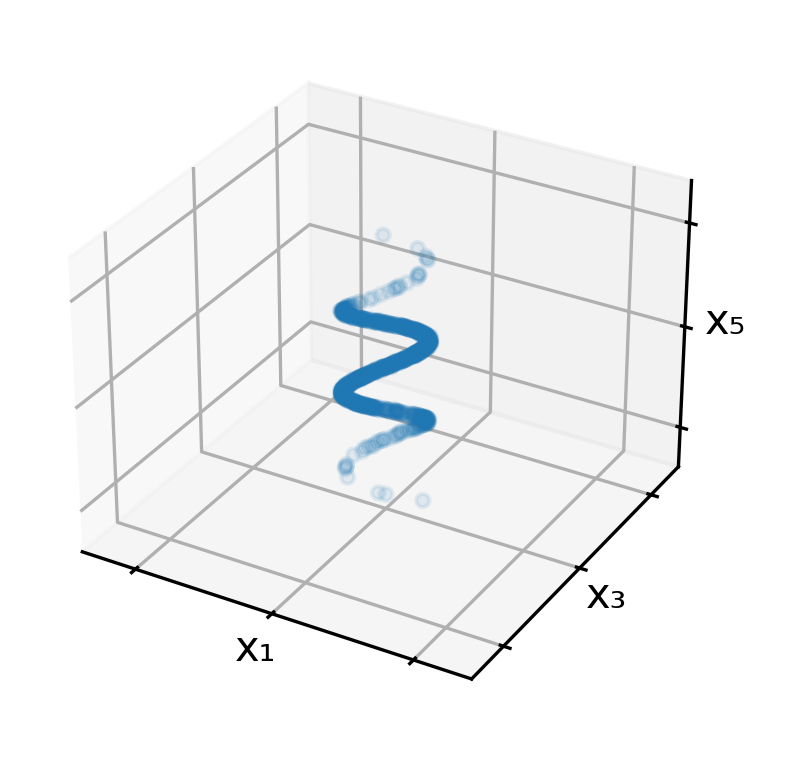

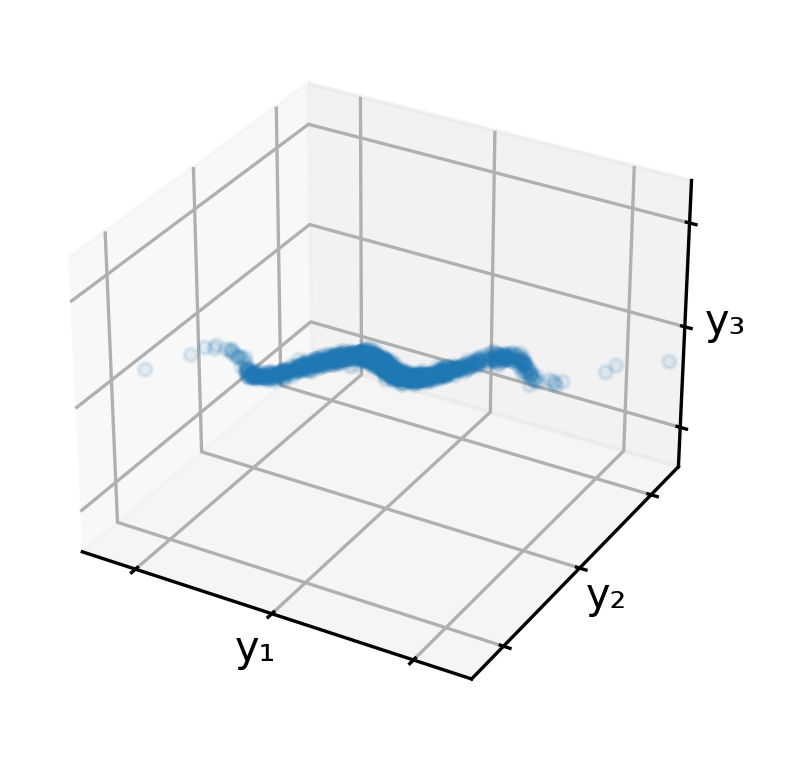

In [2]:
# Construct dataset
def generalised_sinusoid_sampling(dim, latent_dim, num_samples):
    #K the dimension of the manifold
    #N the ambient dimension
    #shearing in the sinusoid formation
    #variances dictate the manifold concentration
    N = dim
    K = latent_dim
    
    # Extract variances for the latent space (manifold) and ambient space
    manifold_variances = 3 * torch.ones(K)
    ambient_variances = 1e-3 * torch.ones(N-K)

    # Sample from the K-dimensional latent space (manifold)
    z_samples = torch.randn(num_samples, K) * torch.sqrt(manifold_variances)

    # Initialize random shears for the off-manifold (N-K) dimensions
    off_manifold_shears = torch.rand(N - K, K) * (2 - 1) + 1  # Random values between [1, 2]

    # Generate the off-manifold samples using the shear vectors and z_samples
    off_manifold_means = []
    for j in range(N - K):
        shear_j = off_manifold_shears[j]  # Get the shear vector for the j-th off-manifold dimension
        off_manifold_mean = torch.sin(z_samples @ shear_j.unsqueeze(1))  # Sinusoidal transformation for off-manifold
        off_manifold_means.append(off_manifold_mean.squeeze(1))  # Squeeze to get correct shape

    # Stack the off-manifold dimensions together
    off_manifold_means = torch.stack(off_manifold_means, dim=1)

    # Generate ambient samples for the remaining (N-K) dimensions
    off_manifold_samples = off_manifold_means + torch.randn(num_samples, N - K) * torch.sqrt(ambient_variances)

    # Combine the manifold and ambient samples
    samples = torch.cat([off_manifold_samples, z_samples], dim=1)
    
    return samples

def random_gaussian_rip(n, m):
    return torch.randn(n, m) / (m**0.5)  # Variance 1/m scaling

dim = 5
num_samples = 1000
num_ref_samples = 50
noise_level = 0.1

data_clean = generalised_sinusoid_sampling(dim, 1, num_samples)
ref_data = data_clean[torch.randperm(data_clean.shape[0])[:num_ref_samples]]

cor_dim = 3
forward_operator = random_gaussian_rip(cor_dim, dim)

data_train_clean = torch.einsum("nm,Nm->Nn", forward_operator, data_clean) 
data_train = data_train_clean + noise_level * torch.randn_like(data_train_clean)

train_loader = DataLoader(data_train, batch_size=128, shuffle=False)
clean_train_loader = DataLoader(data_clean, batch_size=128, shuffle=False)

# plot data
fig = plt.figure(figsize=(3., 3.), dpi=300)
ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,0], data_clean[:,2], data_clean[:,4], alpha=0.1, s=10)
ax.set(xlim=(-7,7), ylim=(-7,7), zlim=(-7,7))
ax.set_xlabel('x₁'), ax.set_ylabel('x₃'), ax.set_zlabel('x₅')
ax.set_xticklabels([]), ax.set_yticklabels([]), ax.set_zticklabels([])
ax.xaxis.labelpad = -15; ax.yaxis.labelpad = -15; ax.zaxis.labelpad = -15
plt.savefig(os.path.join(results_folder_path,"clean_data_dims135.png"), bbox_inches="tight", pad_inches=0.0)
plt.show()

fig = plt.figure(figsize=(3., 3.), dpi=300)
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1, s=10)
ax.set(xlim=(-7,7), ylim=(-7,7), zlim=(-7,7))
ax.set_xlabel('y₁'), ax.set_ylabel('y₂'), ax.set_zlabel('y₃')
ax.set_xticklabels([]), ax.set_yticklabels([]), ax.set_zticklabels([])
ax.xaxis.labelpad = -15; ax.yaxis.labelpad = -15; ax.zaxis.labelpad = -15
plt.savefig(os.path.join(results_folder_path,"corrupted_data.png"), bbox_inches="tight", pad_inches=0.0)
plt.show()

In [3]:
class LinearForward(nn.Module):
    def __init__(self, linear):
        super().__init__()
        self.A = linear

    def forward(self, x):
        return torch.einsum("nm,Nm->Nn", self.A.to(x.device), x) 

In [4]:
class ResidualBlockMLP(nn.Module):
    def __init__(self, dim, hidden_dim):
        super().__init__()
        hidden_dim = hidden_dim
        self.fc1 = nn.Linear(2*dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 2*dim)
        
    def forward(self, x):
        identity = x
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out += identity
        return out

class ResNetMLP(nn.Module):
    def __init__(self, cor_dim, dim, hidden_dim, n_blocks):
        super().__init__()
        self.embedding = nn.Linear(cor_dim, 2 * dim)
        self.blocks = nn.Sequential(
            *[ResidualBlockMLP(dim, hidden_dim) for _ in range(n_blocks)]
        )

    def forward(self, x):
        y = self.embedding(x)
        return self.blocks(y)

In [5]:
# Define the normalizing flow model
def create_flow_model(dim, n_flows, order, unit_det=False):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(TanhParityTransform(dim, order=order, parity=i))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return NFlowVectorDiffeomorphism(dim, flows.Flow(transform=flow_transforms, distribution=base_dist))

In [6]:
# Define the conditional normalizing flow model
def create_conditional_distribution_model(cor_dim, dim, hidden_dim, n_blocks):
    context_encoder = ResNetMLP(cor_dim, dim, hidden_dim, n_blocks)
    return distributions.ConditionalDiagonalNormal(shape=[dim], context_encoder=context_encoder)


In [7]:
# Initialize the model
forward = LinearForward(forward_operator)

n_flows = 4
order = 2
prior_nflow_diffeo = create_flow_model(dim, n_flows, order)

n_blocks = 1
hidden_dim = 8
posterior_dist = create_conditional_distribution_model(cor_dim, dim, hidden_dim, n_blocks)

model = RiemannianAmbientFlowProblem(forward, prior_nflow_diffeo, posterior_dist, noise_level, low_rank_reg_param=low_rank_reg_param, clean_data_reg_param=clean_data_reg_param).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [8]:
# Training loop
def train(model, train_loader, optimizer, n_epochs, ref_data):
    x = ref_data.to(device)
    for epoch in range(n_epochs):
        for y in tqdm(train_loader):
            optimizer.zero_grad()
            
            y = y.to(device)
            # Compute loss
            loss = model.reconstruction_loss(y, x=x)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

In [9]:
# Train the model
train(model, train_loader, optimizer, n_epochs, ref_data)

100%|██████████| 8/8 [00:00<00:00, 32.28it/s]


Epoch 1/500, Loss: 208.3769


100%|██████████| 8/8 [00:00<00:00, 34.01it/s]


Epoch 2/500, Loss: 215.1779


100%|██████████| 8/8 [00:00<00:00, 32.67it/s]


...

Epoch 498/500, Loss: 6.7376


100%|██████████| 8/8 [00:00<00:00, 34.99it/s]


Epoch 499/500, Loss: 6.6946


100%|██████████| 8/8 [00:00<00:00, 34.97it/s]

Epoch 500/500, Loss: 6.7221


In [10]:
# Generate samples
@torch.no_grad()
def generate_samples(model, n_samples):
    samples = model.sample(n_samples).cpu()
    return samples

In [11]:
# Generate conditional samples
@torch.no_grad()
def generate_samples_with_context(model, n_samples, context):
    samples = model.sample(n_samples, context=context[None]).squeeze().cpu()
    return samples

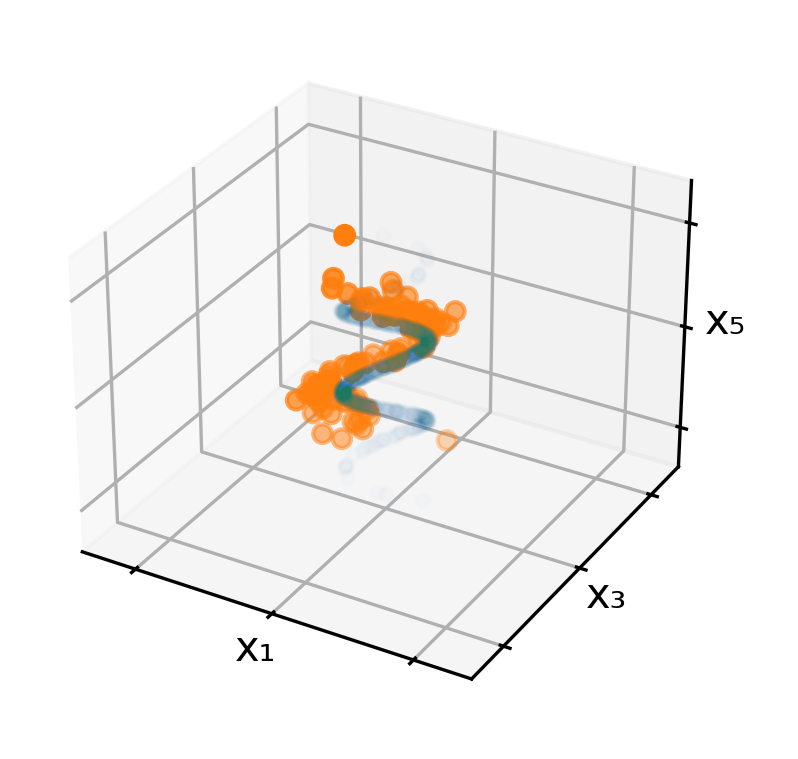

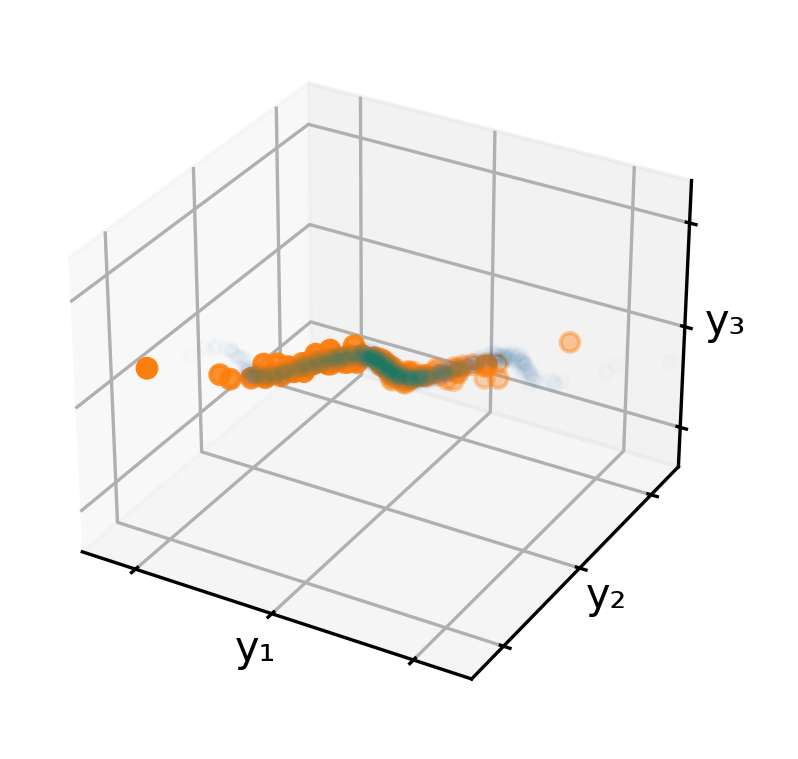

In [12]:
# Visualize generated samples
samples = generate_samples(model.phi_prior.nflow, 100)
cor_samples = torch.einsum("nm,Nm->Nn", forward_operator, samples) 

# dims 1,3,5
fig = plt.figure(figsize=(3., 3.), dpi=300)
ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,0], data_clean[:,2], data_clean[:,4], alpha=0.01, s=10)
ax.scatter(samples[:,0], samples[:,2], samples[:,4])
ax.set(xlim=(-7,7), ylim=(-7,7), zlim=(-7,7))
ax.set_xlabel('x₁'), ax.set_ylabel('x₃'), ax.set_zlabel('x₅')
ax.set_xticklabels([]), ax.set_yticklabels([]), ax.set_zticklabels([])
ax.xaxis.labelpad = -15; ax.yaxis.labelpad = -15; ax.zaxis.labelpad = -15
plt.savefig(os.path.join(results_folder_path,"samples_dims135.png"), bbox_inches="tight", pad_inches=0.0)
plt.show()

fig = plt.figure(figsize=(3., 3.), dpi=300)
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.01, s=10)
ax.scatter(cor_samples[:,0], cor_samples[:,1], cor_samples[:,2])
ax.set(xlim=(-7,7), ylim=(-7,7), zlim=(-7,7))
ax.set_xlabel('y₁'), ax.set_ylabel('y₂'), ax.set_zlabel('y₃')
ax.set_xticklabels([]), ax.set_yticklabels([]), ax.set_zticklabels([])
ax.xaxis.labelpad = -15; ax.yaxis.labelpad = -15; ax.zaxis.labelpad = -15
plt.savefig(os.path.join(results_folder_path,"corrupted_samples.png"), bbox_inches="tight", pad_inches=0.0)
plt.show()

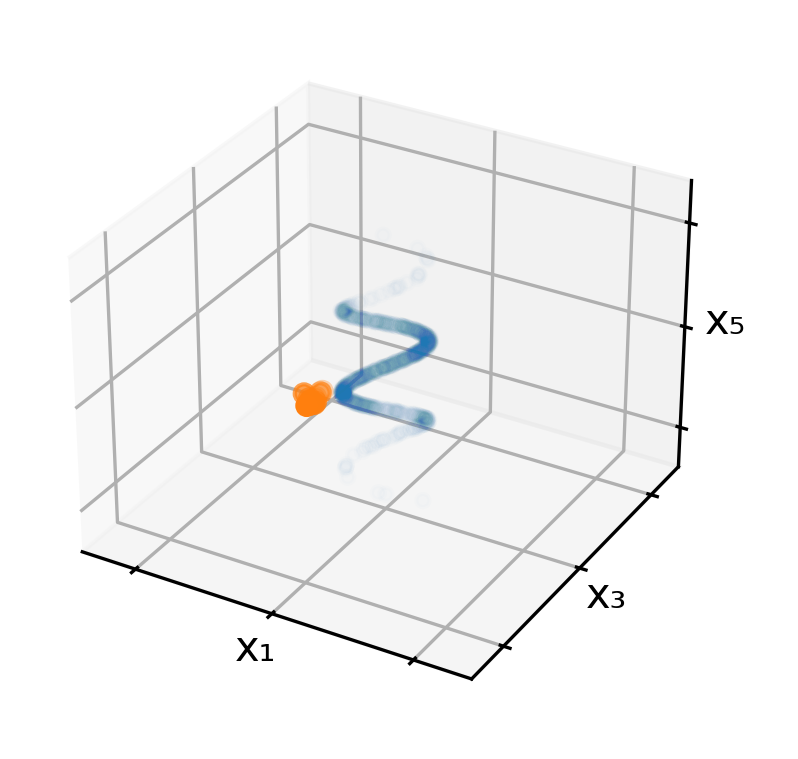

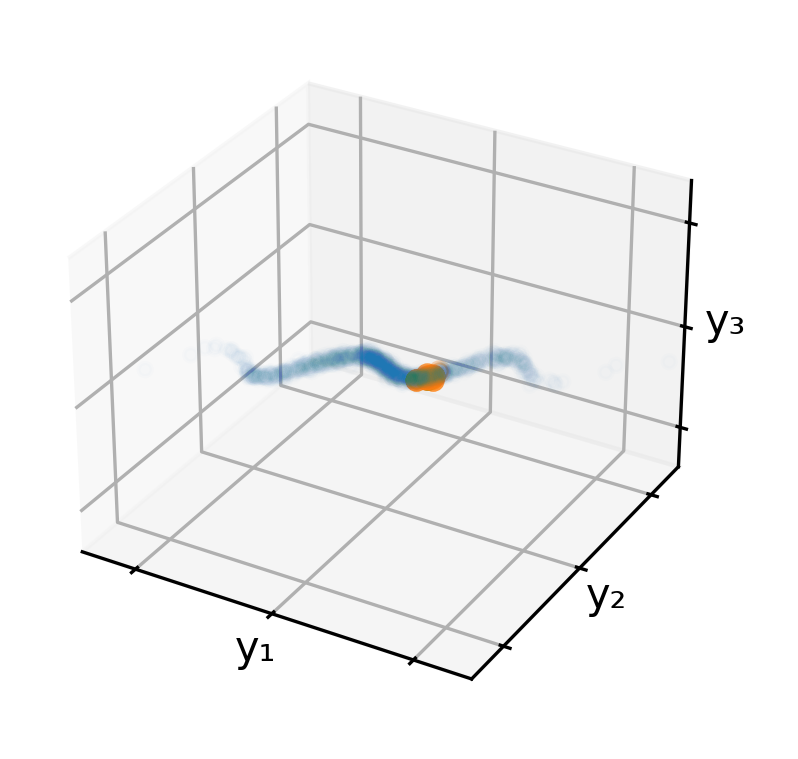

In [13]:
# Visualize generated samples
context = data_train[8]
samples = generate_samples_with_context(model.p_post, 10, context.to(device))
cor_samples = torch.einsum("nm,Nm->Nn", forward_operator, samples) 

fig = plt.figure(figsize=(3., 3.), dpi=300)
ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,0], data_clean[:,2], data_clean[:,4], alpha=0.01, s=10)
ax.scatter(samples[:,0], samples[:,2], samples[:,4])
ax.set(xlim=(-7,7), ylim=(-7,7), zlim=(-7,7))
ax.set_xlabel('x₁'), ax.set_ylabel('x₃'), ax.set_zlabel('x₅')
ax.set_xticklabels([]), ax.set_yticklabels([]), ax.set_zticklabels([])
ax.xaxis.labelpad = -15; ax.yaxis.labelpad = -15; ax.zaxis.labelpad = -15
plt.savefig(os.path.join(results_folder_path,"posterior_samples_dims135.png"), bbox_inches="tight", pad_inches=0.0)
plt.show()

fig = plt.figure(figsize=(3., 3.), dpi=300)
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.01, s=10)
ax.scatter(cor_samples[:,0], cor_samples[:,1], cor_samples[:,2])
ax.scatter(context[0], context[1], context[2])
ax.set(xlim=(-7,7), ylim=(-7,7), zlim=(-7,7))
ax.set_xlabel('y₁'), ax.set_ylabel('y₂'), ax.set_zlabel('y₃')
ax.set_xticklabels([]), ax.set_yticklabels([]), ax.set_zticklabels([])
ax.xaxis.labelpad = -15; ax.yaxis.labelpad = -15; ax.zaxis.labelpad = -15
plt.savefig(os.path.join(results_folder_path,"corrupted_posterior_samples.png"), bbox_inches="tight", pad_inches=0.0)
plt.show()

### Evaluating Geometry ###

In [14]:
# Construct pullback manifold
manifold = StandardPullbackVectorEuclidean(model.phi_prior)

##### RAE from Standard Construction #####

In [15]:
# Construct RAE
epsilon = 0.1
d_epsilon = 1
rae_ = StandardPullbackVectorRiemannianAutoencoder(manifold, epsilon=epsilon, device=device)
rae = StandardPullbackVectorRiemannianAutoencoder(manifold, d_epsilon=d_epsilon, device=device)

constructed a Riemannian autoencoder with d_eps = 1 and effectice eps = 0.0019984645769000053
constructed a Riemannian autoencoder with d_eps = 1 and effectice eps = 0.0019984645769000053


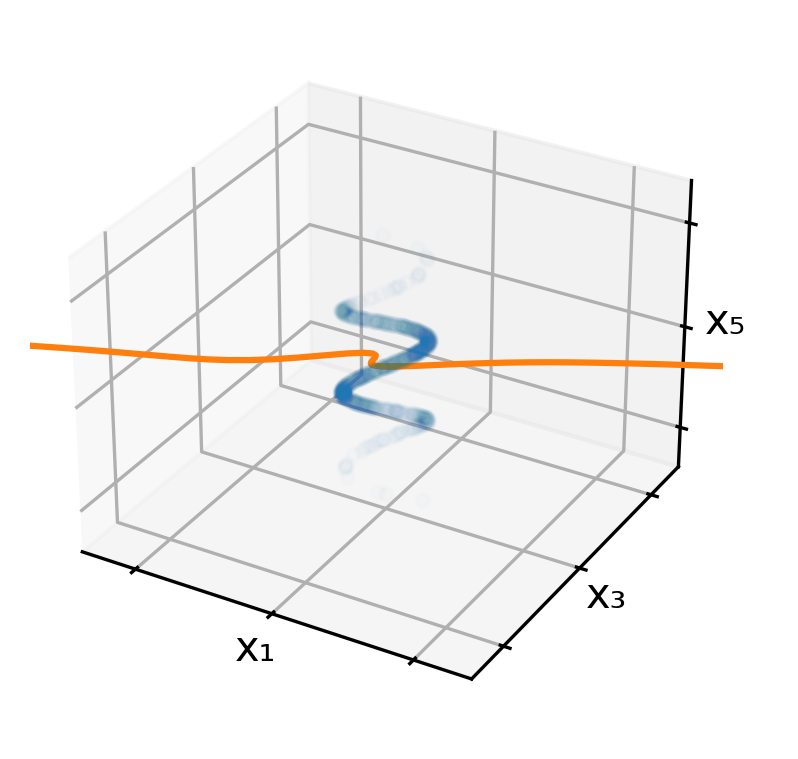

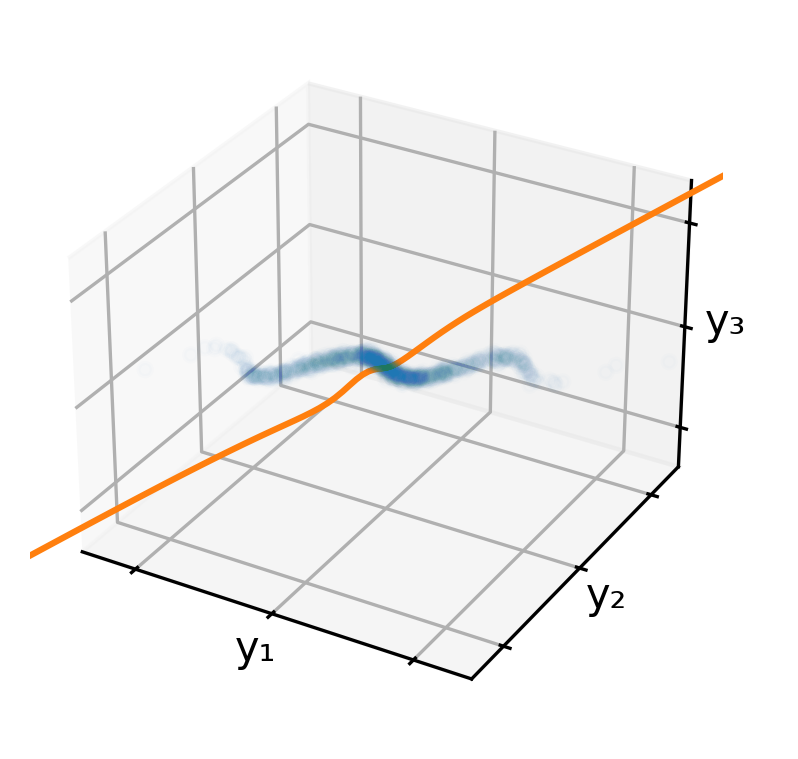

In [16]:
latent_geodesic = torch.linspace(- 5, 5, 100)[:,None].to(device)
geodesic = rae.decode(latent_geodesic).detach().cpu()
cor_geodesic = torch.einsum("nm,Nm->Nn", forward_operator, geodesic) 

fig = plt.figure(figsize=(3., 3.), dpi=300)
ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,0], data_clean[:,2], data_clean[:,4], alpha=0.01, s=10)
ax.plot(geodesic[:,0].numpy(), geodesic[:,2].numpy(), geodesic[:,4].numpy(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.set(xlim=(-7,7), ylim=(-7,7), zlim=(-7,7))
ax.set_xlabel('x₁'), ax.set_ylabel('x₃'), ax.set_zlabel('x₅')
ax.set_xticklabels([]), ax.set_yticklabels([]), ax.set_zticklabels([])
ax.xaxis.labelpad = -15; ax.yaxis.labelpad = -15; ax.zaxis.labelpad = -15
plt.savefig(os.path.join(results_folder_path,"latent_geodesic_dims135.png"), bbox_inches="tight", pad_inches=0.0)
plt.show()

fig = plt.figure(figsize=(3., 3.), dpi=300)
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.01, s=10)
ax.plot(cor_geodesic[:,0].numpy(), cor_geodesic[:,1].numpy(), cor_geodesic[:,2].numpy(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.set(xlim=(-7,7), ylim=(-7,7), zlim=(-7,7))
ax.set_xlabel('y₁'), ax.set_ylabel('y₂'), ax.set_zlabel('y₃')
ax.set_xticklabels([]), ax.set_yticklabels([]), ax.set_zticklabels([])
ax.xaxis.labelpad = -15; ax.yaxis.labelpad = -15; ax.zaxis.labelpad = -15
plt.savefig(os.path.join(results_folder_path,"corrupted_latent_geodesic.png"), bbox_inches="tight", pad_inches=0.0)
plt.show()

##### RAE from Low Rank Approximation #####

In [17]:
rec_data_train = torch.zeros(data_train.shape[0], dim)
for i, context in enumerate(data_train):
    samples = generate_samples_with_context(model.p_post, 10, context.to(device))
    rec_data_train[i] = samples.mean(0)

In [18]:
l2_tpca_rae = l2TangentSpacePCAPullbackVectorRiemannianAutoencoder(manifold, ref_data.to(device), 1)

constructed a Riemannian autoencoder with latent dimension = 1 and effectice eps = 0.3494739234447479


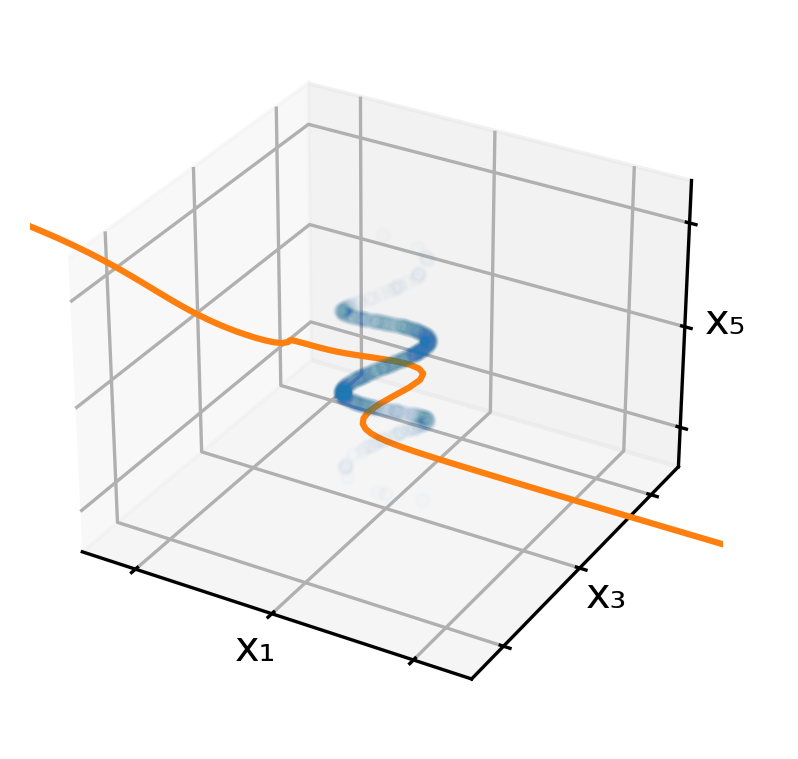

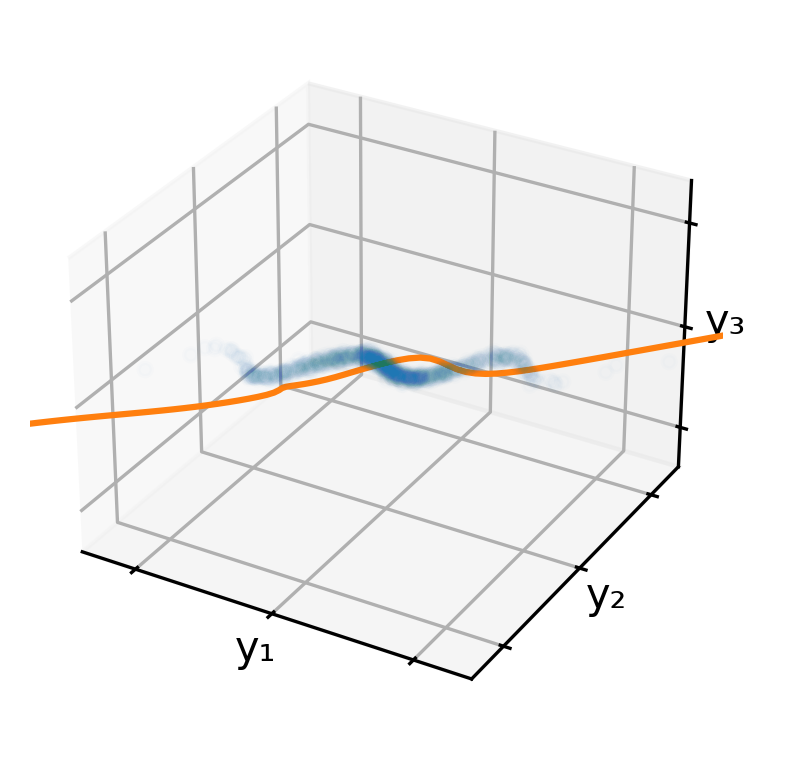

In [19]:
latent_geodesic = torch.linspace(- 25, 25, 100)[:,None].to(device)
l2_tpca_geodesic = l2_tpca_rae.decode(latent_geodesic).detach().cpu()
cor_l2_tpca_geodesic = torch.einsum("nm,Nm->Nn", forward_operator, l2_tpca_geodesic)

fig = plt.figure(figsize=(3., 3.), dpi=300)
ax = plt.axes(projection='3d')
ax.scatter(data_clean[:,0], data_clean[:,2], data_clean[:,4], alpha=0.01, s=10)
ax.plot(l2_tpca_geodesic[:,0].numpy(), l2_tpca_geodesic[:,2].numpy(), l2_tpca_geodesic[:,4].numpy(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.set(xlim=(-7,7), ylim=(-7,7), zlim=(-7,7))
ax.set_xlabel('x₁'), ax.set_ylabel('x₃'), ax.set_zlabel('x₅')
ax.set_xticklabels([]), ax.set_yticklabels([]), ax.set_zticklabels([])
ax.xaxis.labelpad = -15; ax.yaxis.labelpad = -15; ax.zaxis.labelpad = -15
plt.savefig(os.path.join(results_folder_path,"l2_tpca_geodesic_dims135.png"), bbox_inches="tight", pad_inches=0.0)
plt.show()

fig = plt.figure(figsize=(3., 3.), dpi=300)
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.01, s=10)
ax.plot(cor_l2_tpca_geodesic[:,0].numpy(), cor_l2_tpca_geodesic[:,1].numpy(), cor_l2_tpca_geodesic[:,2].numpy(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.set(xlim=(-7,7), ylim=(-7,7), zlim=(-7,7))
ax.set_xlabel('y₁'), ax.set_ylabel('y₂'), ax.set_zlabel('y₃')
ax.set_xticklabels([]), ax.set_yticklabels([]), ax.set_zticklabels([])
ax.xaxis.labelpad = -15; ax.yaxis.labelpad = -15; ax.zaxis.labelpad = -15
plt.savefig(os.path.join(results_folder_path,"corrupted_l2_tpca_geodesic.png"), bbox_inches="tight", pad_inches=0.0)
plt.show()